# Set up

In [1]:
import scyan as sy
import os
import glob
import anndata
import re
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scanpy as sc
import scanpy.external as sce


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


In [2]:
print(sy.__version__)


1.5.1


In [24]:
# define the working path
panel = "PM1"
data_path='/home/jupyter/projects/pre-ra/flow/raw-data/' + panel + '/labelled-expr/cache/'
fig_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/results/' + panel + '_global_subsample'  + "/""/"
proj_name = 'pre-ra_flow_clustering_' + panel
output_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/data/' +panel +'/'

if not os.path.exists(fig_path):
    os.makedirs(fig_path)
    
if not os.path.exists(output_path):
    os.makedirs(output_path)
    
# define scanpy verbose levels
sc.settings.verbosity = 3
sc.settings.figdir = fig_path
sc.settings.n_jobs = -1

# Helper Functions 

In [4]:
# make a function to find files
def get_filepaths_with_glob(root_path: str, file_regex: str):
    return glob.glob(os.path.join(root_path, file_regex))


def subset_files(file_names, substrings):
    # Initialize an empty list to store the matching file names
    matching_files = []

    # Iterate through each file name
    for file_name in file_names:
        # Check if any substring is present in the file name
        if any(substring in file_name for substring in substrings):
            # If yes, add the file name to the matching list
            matching_files.append(file_name)

    return matching_files

In [35]:
# load data from csv
def read_one(file_path):
    #print(file_path)
    adata = sy.read_csv(file_path, marker_regex='^cd|^hla|tcr|ig|^ccr|klrg|^cx',  exclude_markers=None)
    adata.obs["batch"] = re.findall( 'B\\d\\d\\d', file_path)[0]
    adata.obs["panel"] = re.findall( 'PB1|PT1|PM1|PS1', file_path)[0]

    return adata


In [6]:
# Function to check if any substring is present in the file name
def contains_substring(file_name, substrings):
    return any(substring in file_name for substring in substrings)

In [7]:
### UMAP helper plot, define a helper function to set a single column for our UMAP figure legends. 
def one_col_lgd(umap):
    legend = umap.legend(bbox_to_anchor=[1.00, 0.5],
    loc='center left', ncol=1, prop={'size': 6})
    legend.get_frame().set_linewidth(0.0)
    for handle in legend.legendHandles:
        handle.set_sizes([25.0])
    return legend

# Load files

In [8]:
flow_files=get_filepaths_with_glob(data_path, '*/*transform_labelled_expr.csv')


In [9]:
### read in meta data and pull only non duplicate samples to anndata

freq_tbl = pd.read_csv('/home/jupyter/projects/pre-ra/flow/01-qc-reports/data/' + panel+ '/freq_tbl_sample_info_' + panel + '.csv')

In [10]:
freq_tbl.head()

,full_filename,labels,counts,frequency_live,total_counts,sample_id,barcode,l1_labels,filename,panel,...,file.fileType,file.majorVersion,subject.id,subject.biologicalSex,subject.birthYear,subject.ethnicity,subject.partnerCode,subject.race,subject.subjectGuid,cohort.cohortGuid
0,/home//jupyter//projects/pre-ra//flow//raw-dat...,Unknown,80029,0.340685,234906,PB00052-02,2c6547d8484d11ee9faf96b4760239f7,unknown,Flow_Cyanno_PM1_PB00052-02_summary_frequency_s...,PM1,...,FlowCytometry-summary-frequency-stats,2,f8424819-e5c7-44fd-b19c-12d8a5dd0771,Female,1963,Non-Hispanic origin,CU,Caucasian,CU1009,CU1
1,/home//jupyter//projects/pre-ra//flow//raw-dat...,b_cells,16974,0.072259,234906,PB00052-02,2c6547ec484d11ee9faf96b4760239f7,b_cells,Flow_Cyanno_PM1_PB00052-02_summary_frequency_s...,PM1,...,FlowCytometry-summary-frequency-stats,2,f8424819-e5c7-44fd-b19c-12d8a5dd0771,Female,1963,Non-Hispanic origin,CU,Caucasian,CU1009,CU1
2,/home//jupyter//projects/pre-ra//flow//raw-dat...,basophils,1753,0.007463,234906,PB00052-02,2c656d80484d11ee9faf96b4760239f7,total_myeloid_cells,Flow_Cyanno_PM1_PB00052-02_summary_frequency_s...,PM1,...,FlowCytometry-summary-frequency-stats,2,f8424819-e5c7-44fd-b19c-12d8a5dd0771,Female,1963,Non-Hispanic origin,CU,Caucasian,CU1009,CU1
3,/home//jupyter//projects/pre-ra//flow//raw-dat...,c_dc1,43,0.000183,234906,PB00052-02,2c6901b6484d11ee9faf96b4760239f7,total_myeloid_cells,Flow_Cyanno_PM1_PB00052-02_summary_frequency_s...,PM1,...,FlowCytometry-summary-frequency-stats,2,f8424819-e5c7-44fd-b19c-12d8a5dd0771,Female,1963,Non-Hispanic origin,CU,Caucasian,CU1009,CU1
4,/home//jupyter//projects/pre-ra//flow//raw-dat...,c_dc2,830,0.003533,234906,PB00052-02,2c656100484d11ee9faf96b4760239f7,total_myeloid_cells,Flow_Cyanno_PM1_PB00052-02_summary_frequency_s...,PM1,...,FlowCytometry-summary-frequency-stats,2,f8424819-e5c7-44fd-b19c-12d8a5dd0771,Female,1963,Non-Hispanic origin,CU,Caucasian,CU1009,CU1


In [11]:
# subset flow files based on non duplicate files in meta data
strings = freq_tbl['sample_id'].unique()

# Subset file_names based on matching substrings
matching_files = [file_name for file_name in flow_files if contains_substring(file_name, strings)]

# Print the result
len(matching_files)
len(strings)

136

In [13]:
flow_files[:5]

['/home/jupyter/projects/pre-ra/flow/raw-data/PM1/labelled-expr/cache/ff3d36b0-87f2-47ed-a068-d5c0153860ca/B122_PM1_PB00416-01_live_logical_transform_labelled_expr.csv',
 '/home/jupyter/projects/pre-ra/flow/raw-data/PM1/labelled-expr/cache/c92b8d9a-57dd-456b-a0cd-117dd28bfd21/B015_PM1_PB00074-04_live_logical_transform_labelled_expr.csv',
 '/home/jupyter/projects/pre-ra/flow/raw-data/PM1/labelled-expr/cache/150676ee-afec-4baa-aa11-e870c8e7d24f/B068_PM1_PB00497-01_live_logical_transform_labelled_expr.csv',
 '/home/jupyter/projects/pre-ra/flow/raw-data/PM1/labelled-expr/cache/cc79c5a5-c8a8-457f-bc61-d595338169ba/B014_PM1_PB00052-04_live_logical_transform_labelled_expr.csv',
 '/home/jupyter/projects/pre-ra/flow/raw-data/PM1/labelled-expr/cache/f288b753-92e8-406b-ba3d-da22c7fcbd48/B182_PM1_PB02303-002_live_logical_transform_labelled_expr.csv']

In [36]:

adata = anndata.concat([read_one(p) for p in matching_files], index_unique="-")

In [37]:
len(adata.obs['sample_id'].unique())

134

In [38]:
adata

AnnData object with n_obs × n_vars = 48067994 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel'

## Merge L1 pop

In [39]:
labels_df = freq_tbl[["labels", "l1_labels"]].drop_duplicates()

In [40]:
adata.obs = adata.obs.join(labels_df.set_index('labels'), on='labels')

In [41]:
adata.obs['l1_labels'].unique()

array(['total_myeloid_cells', 't_cells', 'b_cells', 'total_nk_cells',
       'unknown', 'debris', nan], dtype=object)

In [42]:
adata

AnnData object with n_obs × n_vars = 48067994 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels'

In [43]:
# save unscaled adata for subsetting 
adata.write_h5ad(output_path + "adata_preprocess_unscaled_" + panel + ".h5ad")

# QC check

In [44]:
adata = sc.read_h5ad(output_path + "adata_preprocess_unscaled_" + panel + ".h5ad")

In [45]:
adata

AnnData object with n_obs × n_vars = 48067994 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels'

In [46]:
# Important: data from the Cyanno pipeline are already logcile tranformed. 
# No need to redo the transformation
adata.X


array([[3.372092 , 3.8008325, 1.6946281, ..., 1.143497 , 0.9940525,
        1.7135354],
       [1.220723 , 3.7615857, 1.410332 , ..., 1.3095863, 1.1881682,
        1.1907074],
       [1.2425   , 3.8242753, 1.53427  , ..., 1.2057178, 1.2642401,
        1.07325  ],
       ...,
       [1.1046375, 3.7294888, 1.2415951, ..., 1.1469873, 1.3348328,
        1.247587 ],
       [3.500691 , 3.6506295, 1.4932902, ..., 1.3891838, 1.16859  ,
        1.544809 ],
       [1.1302043, 3.2828264, 1.3337764, ..., 1.1010172, 1.5816724,
        1.0736965]], dtype=float32)

In [47]:
## check for NAs in exp array, PM1 has NAns
np.isnan((np.sum(adata.X)))

True

In [48]:
adata.to_df().notnull()

,CD14_logicle,CD45_logicle,CD15_logicle,CD56_logicle,CD304_logicle,CD33_logicle,CD11c_logicle,CX3CR1_logicle,HLA-DR_logicle,CD192 (CCR2)_logicle,...,CD123_logicle,CD172a (SIRPa)_logicle,CD19_logicle,CD370 (CLEC9A)_logicle,CD86_logicle,CD16_logicle,CD197 (CCR7)_logicle,CD274 (PD-L1)_logicle,CD195 (CCR5)_logicle,CD1c_logicle
0-0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1-0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2-0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3-0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4-0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263133-154,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
263134-154,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
263135-154,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
263136-154,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


# Define highly var markers

In [61]:
#### ==== DEFINE HIGHLY VAR MARKERS BASED ON PANEL DF ==== ####
# load panel info for pt1
panel_df = pd.read_csv('/home/jupyter/projects/pre-ra/flow/raw-data/AIFI_flow_' + panel + '_panel_breakdown.csv')
gating_antigens = panel_df.loc[panel_df['used_for_clustering']=='Yes', 'antigen']

gating_antigens = [s + '_logicle' for s in gating_antigens]


# set up the variable
adata.var['antigens'] = adata.var.index.str.replace('_logicle', '')
adata.var[['gating_antigens']] = False
adata.var.loc[adata.var.index.isin(gating_antigens),'gating_antigens'] = True
adata.var[['highly_variable']] = adata.var[['gating_antigens']]
adata.var


,antigens,gating_antigens,highly_variable
CD14_logicle,CD14,True,True
CD45_logicle,CD45,False,False
CD15_logicle,CD15,True,True
CD56_logicle,CD56,True,True
CD304_logicle,CD304,True,True
CD33_logicle,CD33,True,True
CD11c_logicle,CD11c,True,True
CX3CR1_logicle,CX3CR1,True,True
HLA-DR_logicle,HLA-DR,True,True
CD192 (CCR2)_logicle,CD192 (CCR2),True,True


# Subsample

In [63]:
#### ==== SUBSAMPLE ==== ####
sc.pp.subsample(adata,n_obs=3500000, random_state = 123)
print(adata)

AnnData object with n_obs × n_vars = 3500000 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels'
    var: 'antigens', 'gating_antigens', 'highly_variable'


In [64]:
## check for NAs in exp array, PM1 has NAns
np.isnan((np.sum(adata.X)))

False

# Scale

In [65]:
#### ==== SCALE ==== ####
sy.preprocess.scale(adata)
print(adata.X)

[INFO] (scyan.preprocess) Data will be centered and standardised. This is advised only when using spectral/flow data (if this is not your case, consider running 'asinh_transform' instead of 'auto_logicle_transform').


[[-0.16458288 -0.04540104 -0.18359792 ... -0.3074944  -0.35857072
  -0.5151504 ]
 [-0.4157458  -1.2455332  -0.36657253 ...  0.9815863  -0.31778052
  -0.622628  ]
 [-0.0752617  -0.852478   -0.41114962 ...  0.8615954   1.4590093
   3.2398705 ]
 ...
 [-0.3539241   0.04094737 -0.04980556 ... -0.4815829  -0.30786335
  -0.4246231 ]
 [-0.36752978  0.42527005  1.283652   ... -1.6905628  -0.64232093
   0.05214363]
 [-0.30791923 -0.43222553 -0.82326394 ...  0.0310802  -0.26515275
   3.767974  ]]


In [66]:
cell_labels_to_subset_list = adata.obs['l1_labels'].unique()
print(cell_labels_to_subset_list)

print(pd.crosstab(adata.obs['l1_labels'], adata.obs['panel'], margins=True)) 

['t_cells', 'total_myeloid_cells', 'unknown', 'b_cells', 'total_nk_cells', 'debris']
Categories (6, object): ['b_cells', 'debris', 't_cells', 'total_myeloid_cells', 'total_nk_cells', 'unknown']
panel                    PM1      All
l1_labels                            
b_cells               265117   265117
debris                 55983    55983
t_cells              1368249  1368249
total_myeloid_cells   523211   523211
total_nk_cells        347449   347449
unknown               939991   939991
All                  3500000  3500000


# Save Scaled

In [67]:
adata.write_h5ad(output_path  + "adata_preprocess_global_subsample_3.5mill_" + panel + ".h5ad")


# PCA

In [68]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)

computing PCA
    on highly variable genes
    with n_comps=14
    finished (0:00:02)


In [ ]:
sce.pp.harmony_integrate(adata, 'batch', adjusted_basis='X_pca_harmony')


2024-01-17 20:37:50,681 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-01-17 20:41:58,413 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-01-17 20:42:12,712 - harmonypy - INFO - Iteration 1 of 10
2024-01-17 21:07:38,541 - harmonypy - INFO - Iteration 2 of 10
2024-01-17 21:32:46,515 - harmonypy - INFO - Iteration 3 of 10
2024-01-17 21:57:38,266 - harmonypy - INFO - Iteration 4 of 10
2024-01-17 22:22:56,543 - harmonypy - INFO - Iteration 5 of 10
2024-01-17 23:03:45,740 - harmonypy - INFO - Iteration 7 of 10
2024-01-17 23:17:53,769 - harmonypy - INFO - Iteration 8 of 10
2024-01-17 23:28:39,781 - harmonypy - INFO - Iteration 9 of 10
2024-01-17 23:39:27,891 - harmonypy - INFO - Iteration 10 of 10


In [72]:
# replace new pca slot
adata.obsm['X_pca'] = adata.obsm['X_pca_harmony']

In [73]:
sy.tools.umap(adata, markers=gating_antigens)


[INFO] (scyan.tools.representation) Fitting UMAP...


UMAP(min_dist=0.5, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

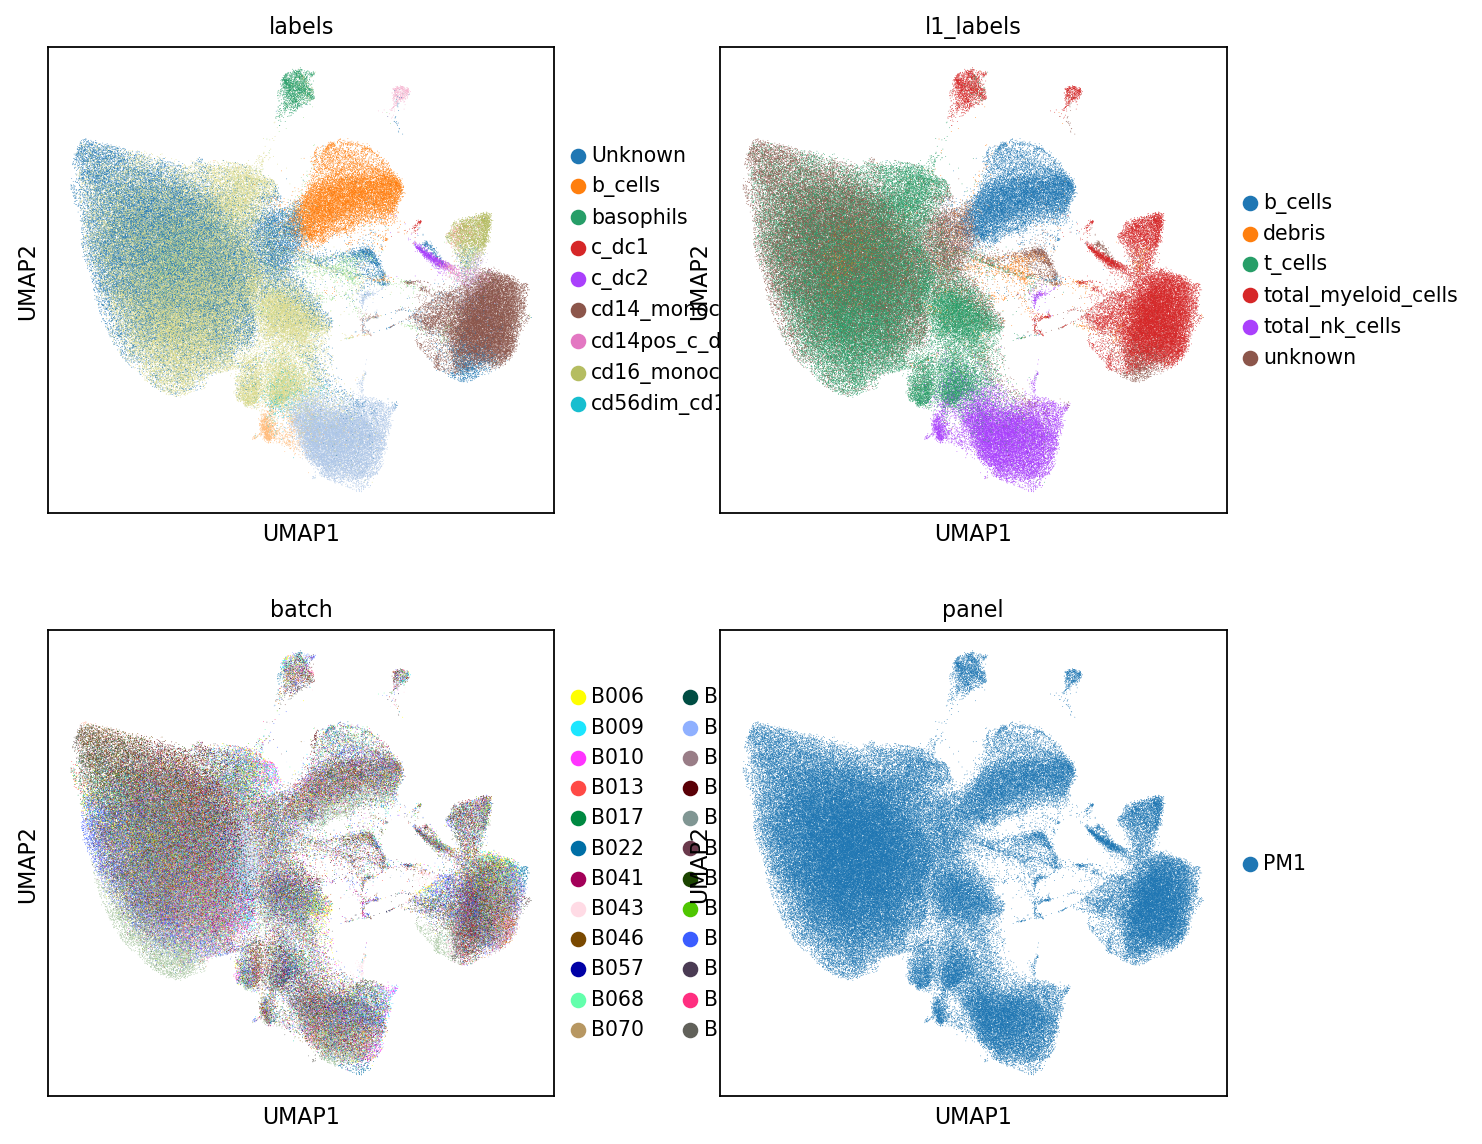

In [76]:
p1 = sy.plot.umap(adata, color=['labels','l1_labels', 'batch','panel'], ncols = 2, return_fig = True, size = .5)
p1.set_size_inches(16.5, 16.5)
p1.savefig(fig_path + "global_subsample_3.5mill_" + "_umap_labels_batch_panel_" +panel + ".png",
               dpi=400, bbox_inches='tight')

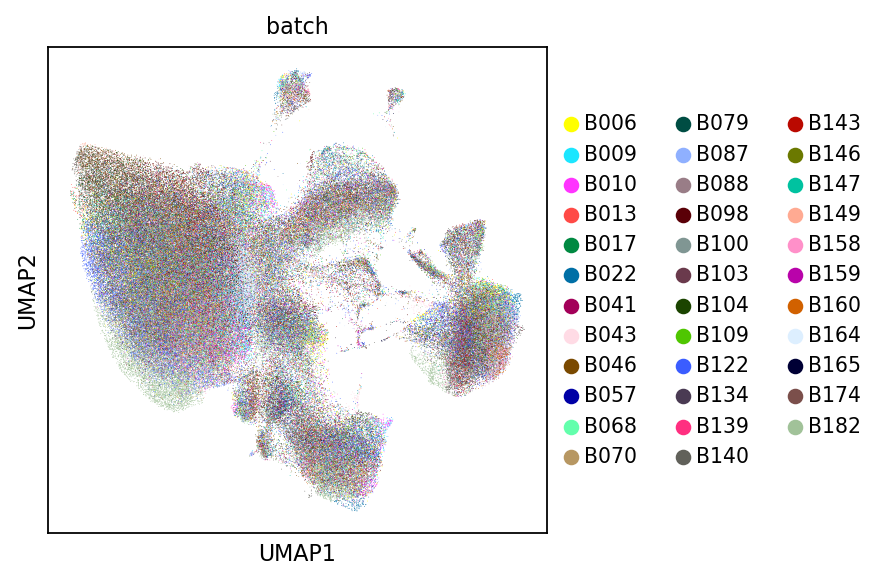

In [85]:
p1 = sy.plot.umap(adata, color=['batch'], ncols = 2, return_fig = True, size = .5)
p1.savefig(fig_path + "global_subsample_3.5mill_" + "_umap_batch_" +panel + ".png",
               dpi=400, bbox_inches='tight')

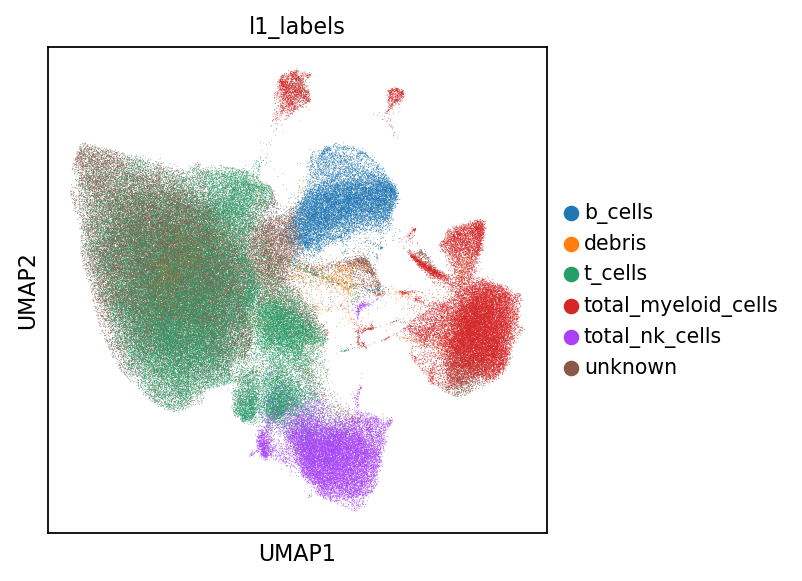

In [79]:
p1 = sy.plot.umap(adata, color=['l1_labels'], ncols = 2, return_fig = True, size = .5)
p1.savefig(fig_path + "global_subsample_3.5mill_" + "_umap_labels_l1_" +panel + ".png",
               dpi=400, bbox_inches='tight')

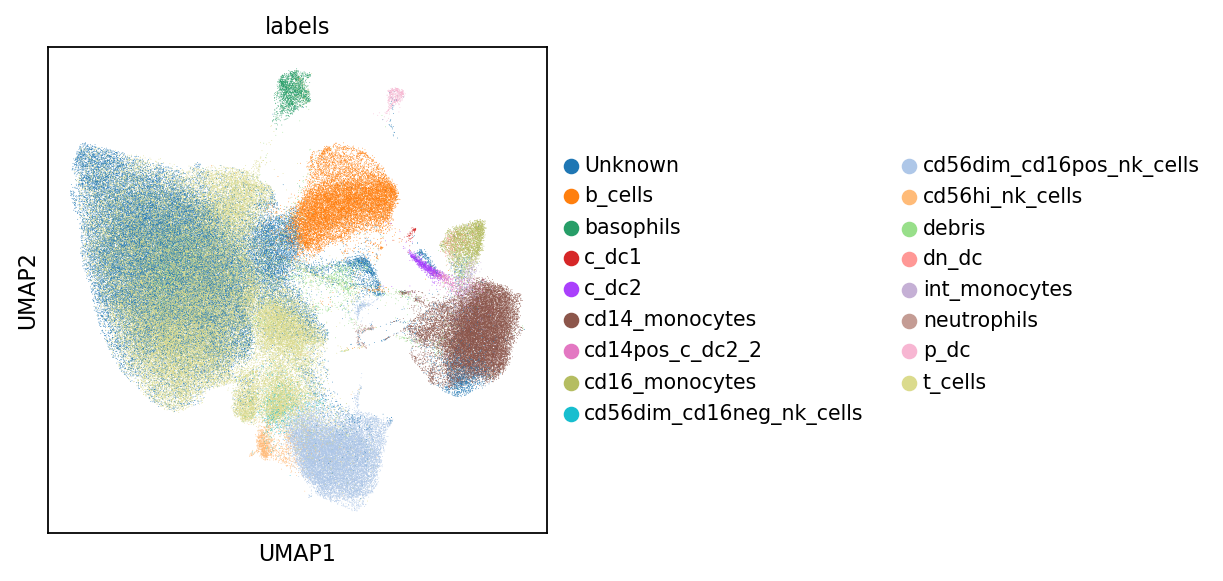

In [80]:
p1 = sy.plot.umap(adata, color=['labels'], ncols = 2, return_fig = True, size = .5)
p1.savefig(fig_path + "global_subsample_3.5mill_" + "_umap_labels_l2_" +panel + ".png",
               dpi=400, bbox_inches='tight')

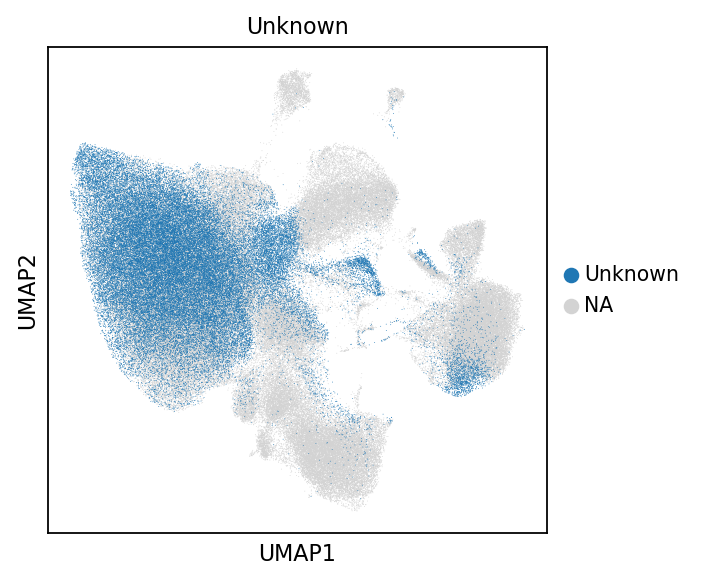

In [81]:
adata.obs["Unknown"] = np.nan
adata.obs.loc[adata.obs['labels']=='Unknown',"Unknown"] = "Unknown"
p1=sy.plot.umap(adata, color=['Unknown'], return_fig = True)
p1.savefig(fig_path + "global_subsample_3.5mill_" + "unknown_pop_" +panel + ".png",
               dpi=400, bbox_inches='tight')

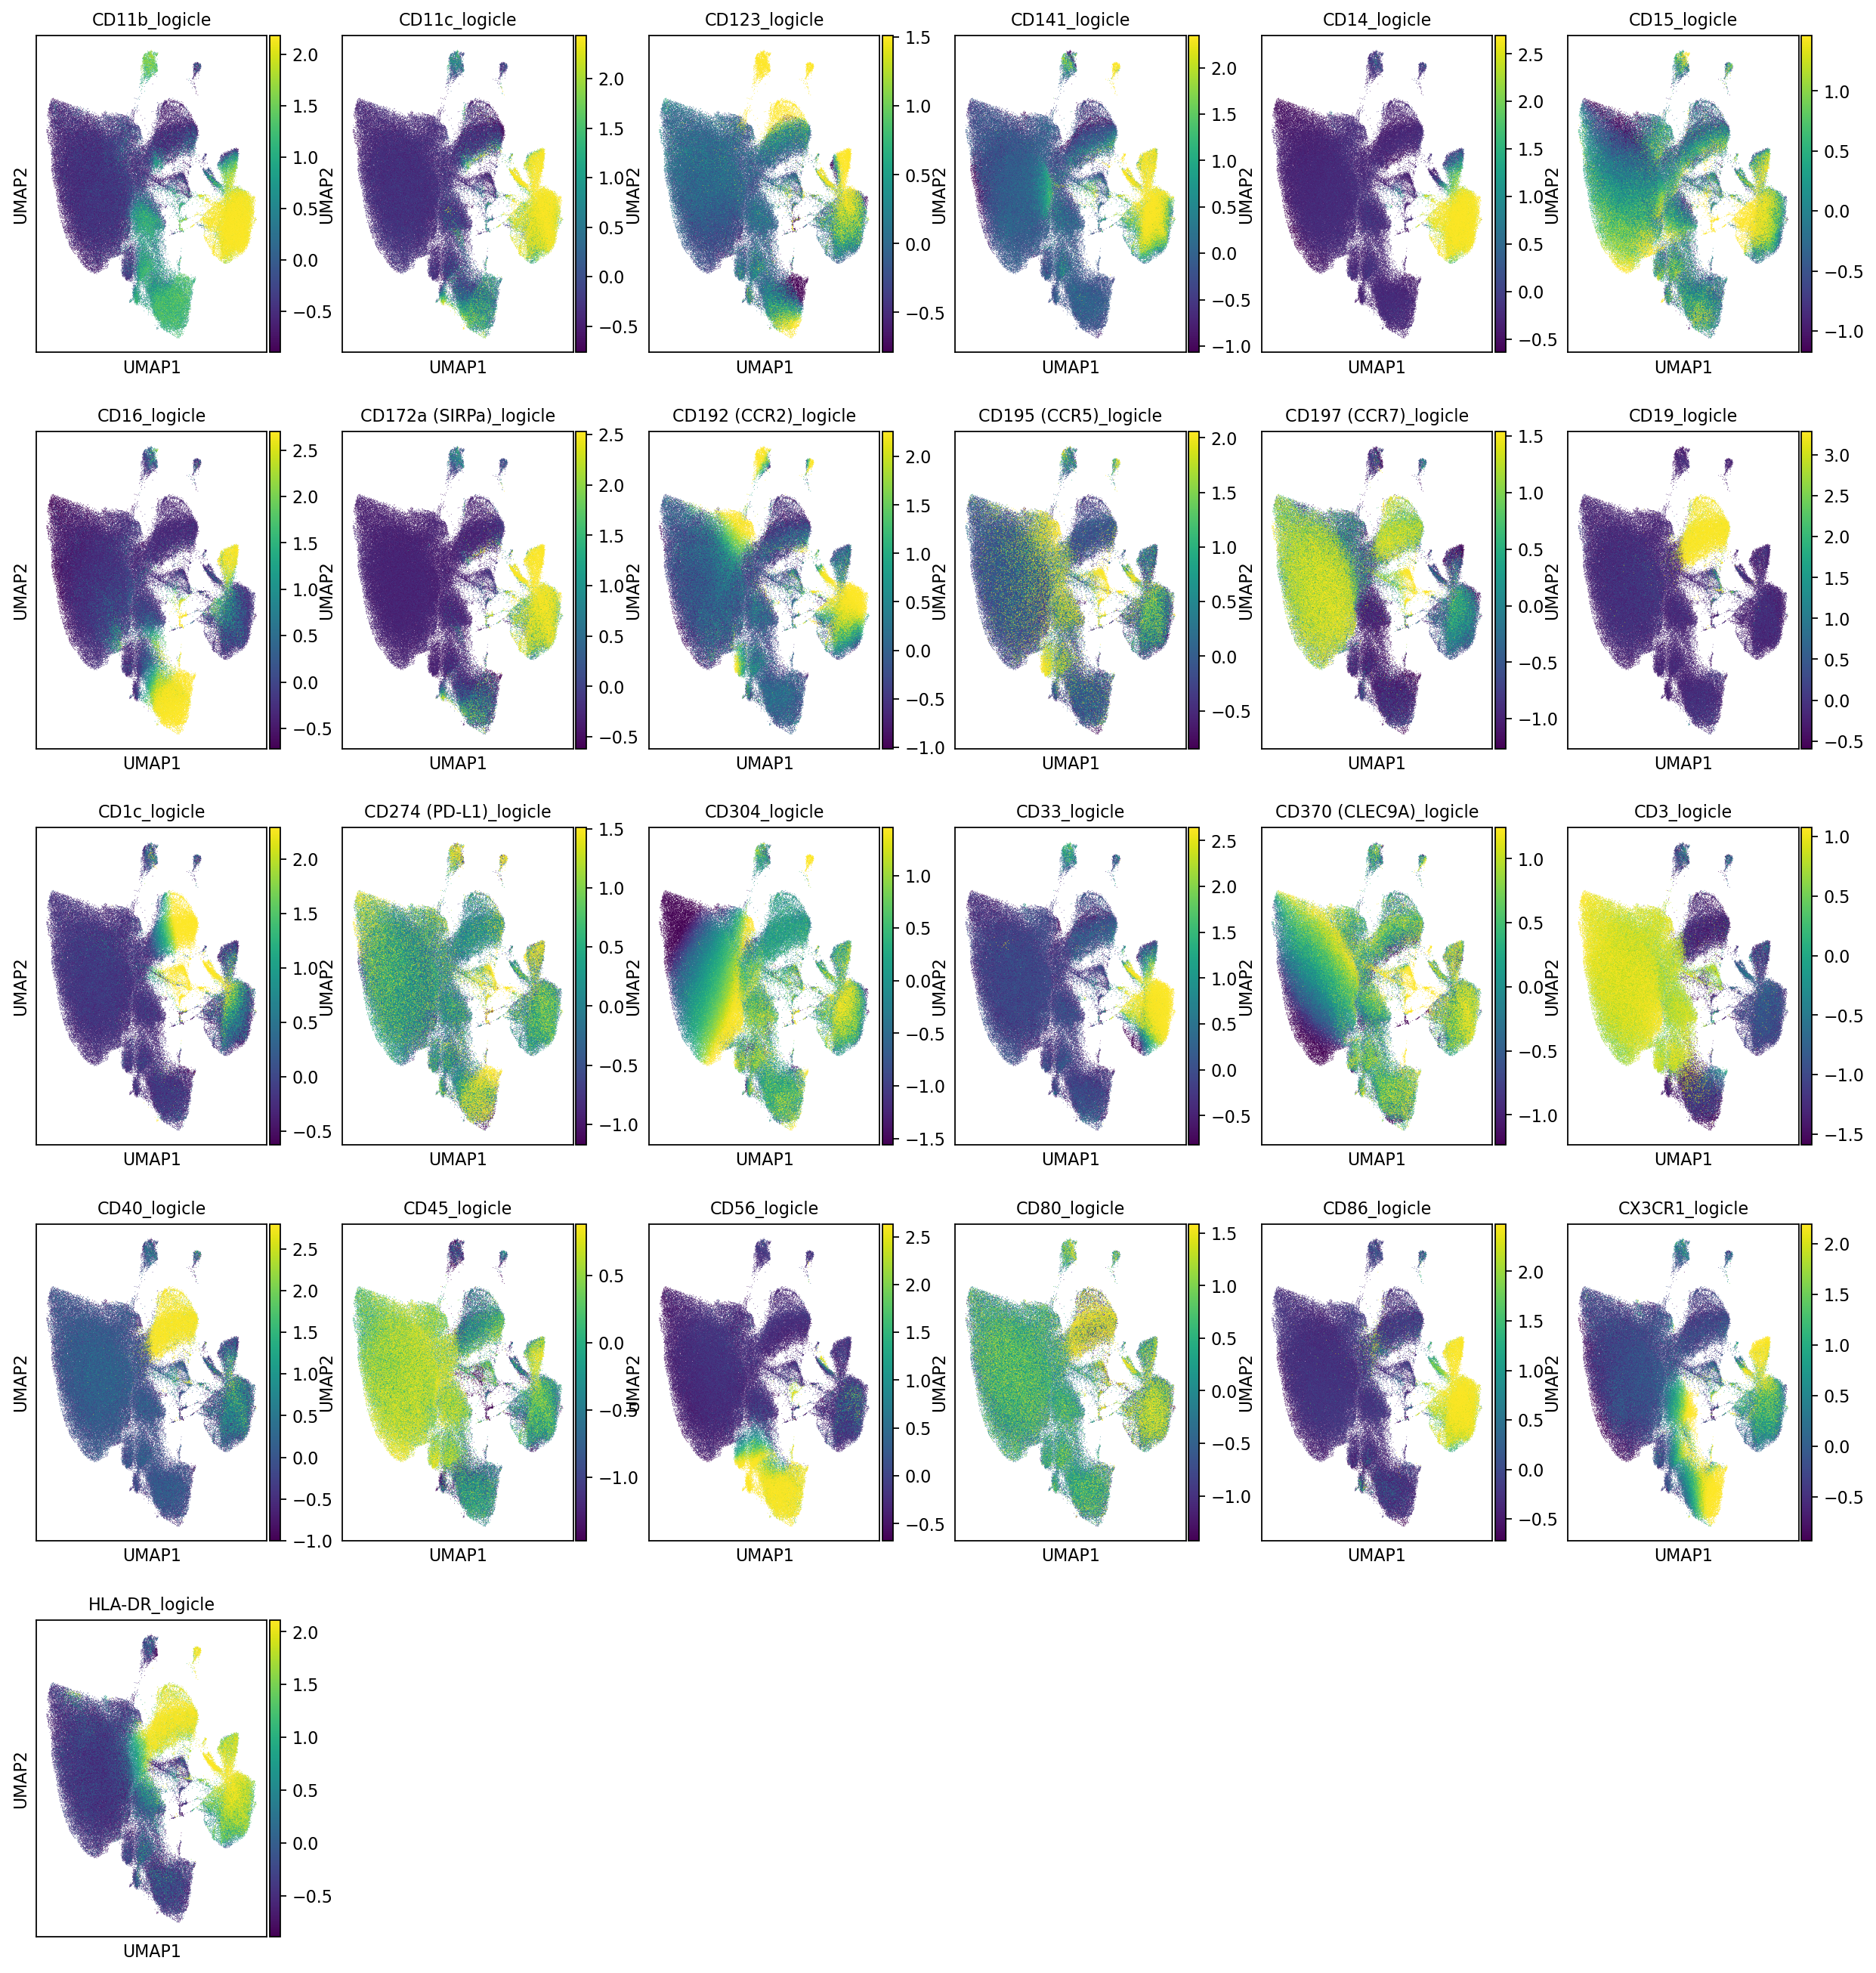

In [82]:
p1=sy.plot.umap(adata, color=adata.var_names.sort_values(),
             ncols=6, show=False, return_fig=True)
p1.set_size_inches(18.5, 18.5)

p1.savefig(fig_path + "global_subsample_3.5mill_" + "_umap_expression_labels_corrected_panel_" +panel + ".png",
               dpi=400, bbox_inches='tight')

In [83]:
adata

AnnData object with n_obs × n_vars = 3500000 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'Unknown'
    var: 'antigens', 'gating_antigens', 'highly_variable'
    uns: 'scyan_scaling_stds', 'scyan_scaling_means', 'pca'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'

In [84]:
adata.write_h5ad(output_path + "adata_preprocess_" + panel + ".h5ad")

# Subset and recluster

In [ ]:
adata = sc.read_h5ad(output_path + "adata_preprocess_" + panel + ".h5ad")

In [ ]:
adata

In [ ]:
# observe l1 subpopulation by mergin
cell_labels_to_subset_list = adata.obs['l1_labels'].unique()

In [ ]:
adata.obs

In [ ]:
pd.crosstab(adata.obs['l1_labels'], adata.obs['panel'], margins=True)

In [ ]:
cell_labels_to_subset_list[0]

In [ ]:
# Iterate through the list of cell labels
for cell_label in cell_labels_to_subset_list[[1]]:
    # Subset the Anndata object based on the current cell label
    sub_adata = adata[adata.obs['l1_labels'].isin([cell_label]), :]
    
    print(sub_adata.obs["l1_labels"].unique())
    
    # retransform rescale after subsetting
    #sy.preprocess.auto_logicle_transform(sub_adata)
    #sy.preprocess.scale(sub_adata)
    
    
    # setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
    sc.pp.pca(sub_adata, svd_solver="arpack", use_highly_variable=True)
    sc.pl.pca_variance_ratio(sub_adata, log=True, n_pcs=50, save='pca_var_' +cell_label+'.png') # scanpy generates the filename automatically
    
    # perform batch correction
    sce.pp.harmony_integrate(sub_adata, 'batch', adjusted_basis='X_pca_harmony')

    # replace new pca slot
    sub_adata.obsm['X_pca'] = sub_adata.obsm['X_pca_harmony']

    # Perform re-clustering on the subset
    sc.pp.neighbors(sub_adata, n_neighbors=20, n_pcs=15, use_rep='X_pca_harmony')
    sc.tl.leiden(sub_adata, resolution=0.5)
    
    # Visualize or perform further analysis on the re-clustered subset
    # (e.g., UMAP, Louvain clustering, etc.)
    #sc.tl.umap(sub_adata, obsm='X_pca_harmony')
    sy.tools.umap(sub_adata, obsm='X_pca_harmony')
    
    p1=sy.plot.umap(sub_adata, color=['l1_labels','labels', 'batch','panel'], ncols =2, return_fig = True)
    p1.savefig(fig_path + cell_label + "_umap_labels_batch_panel_" +panel + ".png",
               dpi=400, bbox_inches='tight')
    
    leiden_umap = sc.pl.umap(sub_adata, color=['leiden'],show=False,
                             legend_fontsize=6, frameon=True, title='Leiden')
    leiden_umap = leiden_umap.get_figure()
    leiden_umap.set_size_inches(5, 5)
    leiden_umap.savefig(fig_path + cell_label + "_umap_leiden_clusters_" +panel + ".png",
                       dpi=400, bbox_inches='tight')
    
    marker_umap =sy.plot.umap(sub_adata, color=adata.var_names.sort_values(),
             ncols=6, show=True, return_fig=True)
    marker_umap.set_size_inches(18.5, 18.5)
    marker_umap.savefig(fig_path + cell_label + "_umap_expression_labels_corrected_panel_" +panel + ".png")
    
    # save 
    sub_adata.write_h5ad(output_path + cell_label + "_adata_subset_clustered_" + panel + ".h5ad")

